In [2]:
import os
import shutil
import random
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import ResNet50, EfficientNetB0
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

/Users/chizobawisdom/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [3]:
SOURCE_DIR  = Path("/Users/chizobawisdom/Downloads/Dataset")   
OUTPUT_DIR = Path.home() / "Downloads/dataset_split"
SPLITS      = {"train": 0.70, "val": 0.15, "test": 0.15}
SEED        = 42
IMAGE_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

random.seed(SEED)

def get_classes(source_dir):
    return [d for d in source_dir.iterdir() if d.is_dir()]

def split_files(files, ratios):
    random.shuffle(files)
    n = len(files)
    n_train = int(n * ratios["train"])
    n_val   = int(n * ratios["val"])
    return {
        "train": files[:n_train],
        "val":   files[n_train:n_train + n_val],
        "test":  files[n_train + n_val:]
    }

classes = get_classes(SOURCE_DIR)
print(f"Found {len(classes)} classes: {[c.name for c in classes]}\n")

for class_dir in classes:
    class_name = class_dir.name
    images = [f for f in class_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]

    if not images:
        print(f"  ⚠ No images found in {class_dir}, skipping.")
        continue

    splits = split_files(images, SPLITS)

    for split_name, split_files_list in splits.items():
        dest = OUTPUT_DIR / split_name / class_name
        dest.mkdir(parents=True, exist_ok=True)
        for f in split_files_list:
            shutil.copy2(f, dest / f.name)

    print(f"  {class_name:15s} → "
          f"train: {len(splits['train']):4d} | "
          f"val: {len(splits['val']):4d} | "
          f"test: {len(splits['test']):4d}")

print(f"\nDone! Split dataset written to: {OUTPUT_DIR.resolve()}")

Found 4 classes: ['Car', 'motorcycle', 'Bus', 'Truck']

  Car             → train:   70 | val:   15 | test:   15
  motorcycle      → train:   70 | val:   15 | test:   15
  Bus             → train:   70 | val:   15 | test:   15
  Truck           → train:   70 | val:   15 | test:   15

Done! Split dataset written to: /Users/chizobawisdom/Downloads/dataset_split


In [4]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

DATA_DIR = os.path.join(os.path.expanduser("~"), "dataset_split")

# Load splits straight from folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

Found 280 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Classes: ['Bus', 'Car', 'Truck', 'motorcycle']


In [5]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="augmentation")


preprocess = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Normalization(mean=[0.485, 0.456, 0.406],
                         variance=[0.052, 0.050, 0.050])  # std²
], name="preprocess")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (train_ds
    .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE))

val_ds = (val_ds
    .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE))

test_ds = (test_ds
    .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

In [6]:
def build_model(num_classes, backbone="resnet50"):
    if backbone == "resnet50":
        base = ResNet50(
            weights="imagenet",
            include_top=False,          # remove original classifier
            input_shape=(*IMG_SIZE, 3)
        )
    else:
        base = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(*IMG_SIZE, 3)
        )

    base.trainable = False              # freeze backbone

    inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512, activation="relu")(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

model = build_model(num_classes, backbone="resnet50")
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 2052      
                                                             

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

Epoch 1/5
9/9 [==============================] - 34s 3s/step - loss: 1.5919 - accuracy: 0.4179 - val_loss: 0.8181 - val_accuracy: 0.6333
Epoch 2/5
9/9 [==============================] - 25s 3s/step - loss: 1.0550 - accuracy: 0.5786 - val_loss: 1.0669 - val_accuracy: 0.5667
Epoch 3/5
9/9 [==============================] - 27s 3s/step - loss: 0.9300 - accuracy: 0.6143 - val_loss: 0.9049 - val_accuracy: 0.6000
Epoch 4/5
9/9 [==============================] - 25s 3s/step - loss: 0.5996 - accuracy: 0.7536 - val_loss: 0.6782 - val_accuracy: 0.6833
Epoch 5/5
9/9 [==============================] - 26s 3s/step - loss: 0.4862 - accuracy: 0.8321 - val_loss: 0.7271 - val_accuracy: 0.7500


In [8]:
# Unfreeze the whole backbone (or just the last N layers)
base_model = model.layers[1]           # the ResNet50 layer
base_model.trainable = True

# Optionally freeze early layers — only fine-tune last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
    ]
)

Epoch 1/30
9/9 [==============================] - 39s 4s/step - loss: 1.0037 - accuracy: 0.6464 - val_loss: 0.9139 - val_accuracy: 0.5500 - lr: 1.0000e-04
Epoch 2/30
9/9 [==============================] - 30s 3s/step - loss: 0.7331 - accuracy: 0.7286 - val_loss: 0.6038 - val_accuracy: 0.7667 - lr: 1.0000e-04
Epoch 3/30
9/9 [==============================] - 28s 3s/step - loss: 0.4670 - accuracy: 0.8036 - val_loss: 0.8001 - val_accuracy: 0.6667 - lr: 1.0000e-04
Epoch 4/30
9/9 [==============================] - 27s 3s/step - loss: 0.2733 - accuracy: 0.9000 - val_loss: 0.8304 - val_accuracy: 0.7167 - lr: 1.0000e-04
Epoch 5/30
9/9 [==============================] - 27s 3s/step - loss: 0.1655 - accuracy: 0.9286 - val_loss: 0.8762 - val_accuracy: 0.7333 - lr: 5.0000e-05
Epoch 6/30
9/9 [==============================] - 28s 3s/step - loss: 0.1280 - accuracy: 0.9500 - val_loss: 0.9660 - val_accuracy: 0.7000 - lr: 5.0000e-05


2/2 [==============================] - 4s 2s/step - loss: 0.6892 - accuracy: 0.6667

Test accuracy: 66.67%
              precision    recall  f1-score   support

         Bus       0.78      0.47      0.58        15
         Car       0.85      0.73      0.79        15
       Truck       0.45      0.60      0.51        15
  motorcycle       0.72      0.87      0.79        15

    accuracy                           0.67        60
   macro avg       0.70      0.67      0.67        60
weighted avg       0.70      0.67      0.67        60



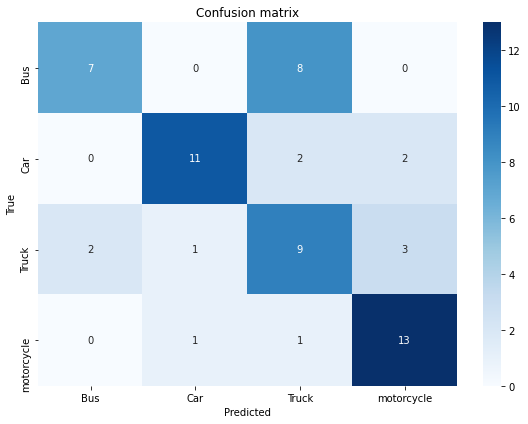

In [9]:
loss, acc = model.evaluate(test_ds)
print(f"\nTest accuracy: {acc:.2%}")

# Confusion matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0).argmax(axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

In [ ]:
# Save in the native Keras format
save_path = os.path.join(os.path.expanduser("~"), "vehicle_classifier.keras")
model.save(save_path)

In [14]:
# Load and predict on a new image
loaded_model = tf.keras.models.load_model(save_path)

# Example prediction
def predict(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = preprocess(tf.expand_dims(img_array, 0))  # add batch dim
    preds = loaded_model.predict(img_array)
    pred_class = class_names[np.argmax(preds)]
    print(f"Predicted class: {pred_class} (confidence: {np.max(preds):.2%})")

predict("/Users/chizobawisdom/Downloads/test_img.jpg")

1/1 [==============================] - 1s 1s/step
Predicted class: Car (confidence: 48.70%)
